In [6]:
import pandas as pd

df = pd.read_csv("../../data/final_reviews.csv")
df.head()

,review_id,review_text,rating,date,bank,source,sentiment_label,sentiment_score,identified_theme
0,1,thanks for you 😘,5,2026-05-16,CBE,Google Play,positive,0.6908,Other
1,2,it's okay,4,2026-05-16,CBE,Google Play,positive,0.2263,Other
2,3,It's not allowing me to transfer money.,2,2026-05-15,CBE,Google Play,neutral,0.0000,Transaction Performance
3,4,IT'S NOT WORK ON HUAWEI DEVICES,4,2026-05-15,CBE,Google Play,neutral,0.0000,Other
4,5,wow,4,2026-05-14,CBE,Google Play,positive,0.5859,Other


In [7]:
df.info()
df.isnull().sum()
df['bank'].value_counts()

<class 'pandas.DataFrame'>
RangeIndex: 913 entries, 0 to 912
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   review_id         913 non-null    int64  
 1   review_text       913 non-null    str    
 2   rating            913 non-null    int64  
 3   date              913 non-null    str    
 4   bank              913 non-null    str    
 5   source            913 non-null    str    
 6   sentiment_label   913 non-null    str    
 7   sentiment_score   913 non-null    float64
 8   identified_theme  913 non-null    str    
dtypes: float64(1), int64(2), str(6)
memory usage: 64.3 KB


bank
Dashen    309
BOA       308
CBE       296
Name: count, dtype: int64

In [8]:
df['date'] = pd.to_datetime(df['date'])

In [9]:
sentiment_by_bank = df.groupby(['bank', 'sentiment_label']).size().unstack()
sentiment_by_bank

sentiment_label,negative,neutral,positive
bank,,,
BOA,69,113,126
CBE,40,83,173
Dashen,53,74,182


In [10]:
sentiment_pct = sentiment_by_bank.div(sentiment_by_bank.sum(axis=1), axis=0) * 100
sentiment_pct

sentiment_label,negative,neutral,positive
bank,,,
BOA,22.402597,36.688312,40.909091
CBE,13.513514,28.040541,58.445946
Dashen,17.152104,23.948220,58.899676


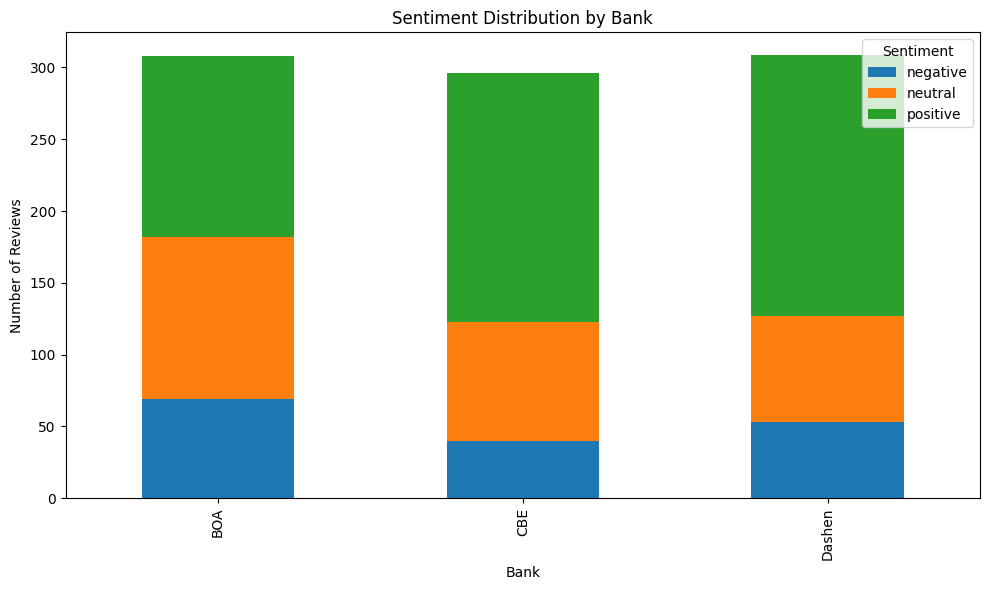

In [11]:
import matplotlib.pyplot as plt

sentiment_by_bank.plot(kind='bar', stacked=True, figsize=(10,6))

plt.title("Sentiment Distribution by Bank")
plt.xlabel("Bank")
plt.ylabel("Number of Reviews")
plt.legend(title="Sentiment")
plt.tight_layout()
plt.show()

In [13]:
!pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)


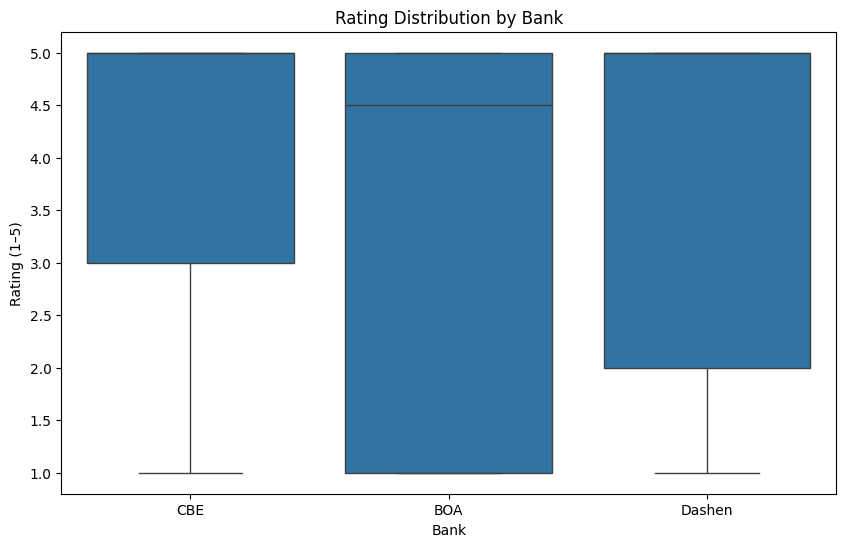

In [14]:
import seaborn as sns

plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='bank', y='rating')

plt.title("Rating Distribution by Bank")
plt.xlabel("Bank")
plt.ylabel("Rating (1–5)")
plt.show()

In [15]:
top_themes = df.groupby(['bank', 'identified_theme']).size().reset_index(name='count')

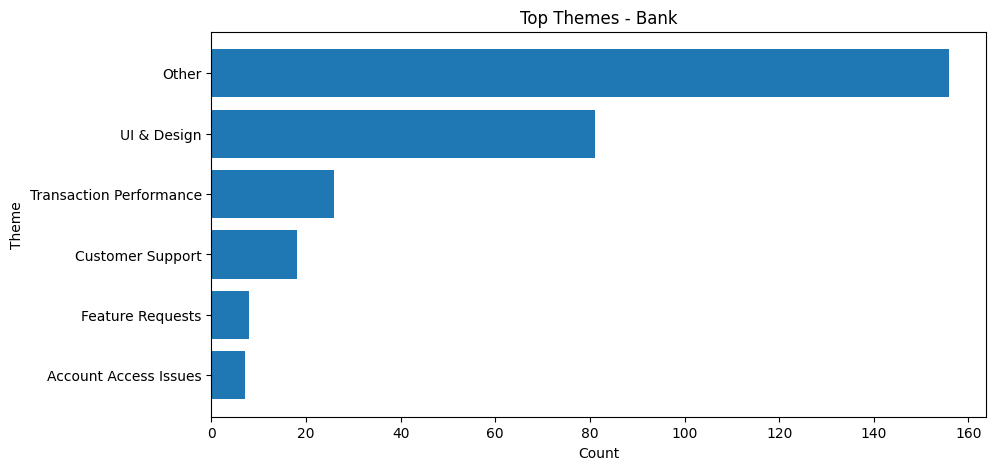

In [16]:
cbe = top_themes[top_themes['bank'] == df['bank'].unique()[0]]
cbe = cbe.sort_values('count', ascending=False).head(10)

plt.figure(figsize=(10,5))
plt.barh(cbe['identified_theme'], cbe['count'])

plt.title("Top Themes - Bank")
plt.xlabel("Count")
plt.ylabel("Theme")
plt.gca().invert_yaxis()
plt.show()

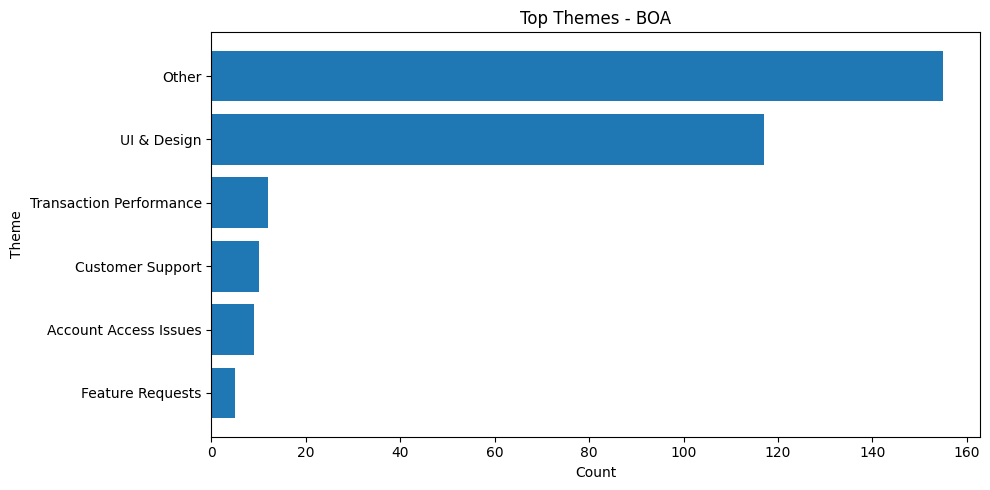

In [17]:
boa = top_themes[top_themes['bank'] == 'BOA']
boa = boa.sort_values('count', ascending=False).head(10)

plt.figure(figsize=(10,5))
plt.barh(boa['identified_theme'], boa['count'])

plt.title("Top Themes - BOA")
plt.xlabel("Count")
plt.ylabel("Theme")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

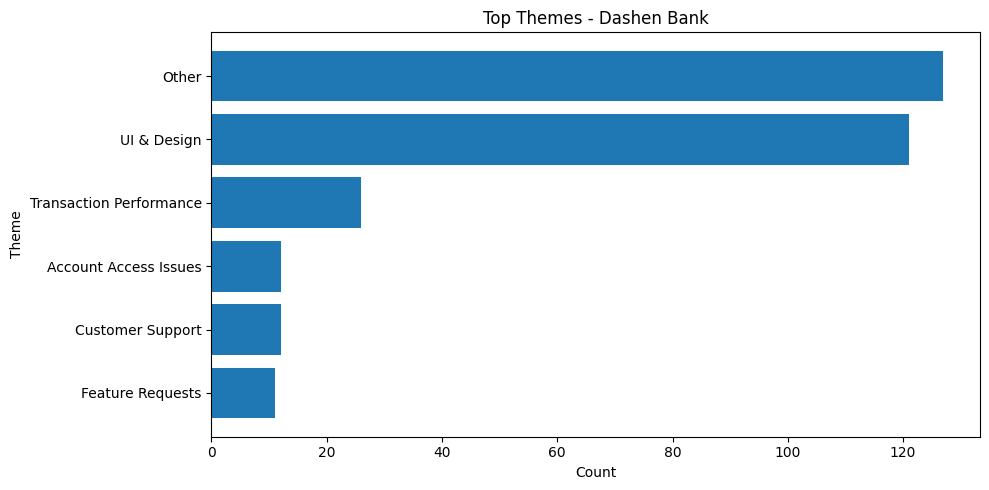

In [18]:
dashen = top_themes[top_themes['bank'] == 'Dashen']
dashen = dashen.sort_values('count', ascending=False).head(10)

plt.figure(figsize=(10,5))
plt.barh(dashen['identified_theme'], dashen['count'])

plt.title("Top Themes - Dashen Bank")
plt.xlabel("Count")
plt.ylabel("Theme")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [19]:
df['bank'].unique()

<StringArray>
['CBE', 'BOA', 'Dashen']
Length: 3, dtype: str

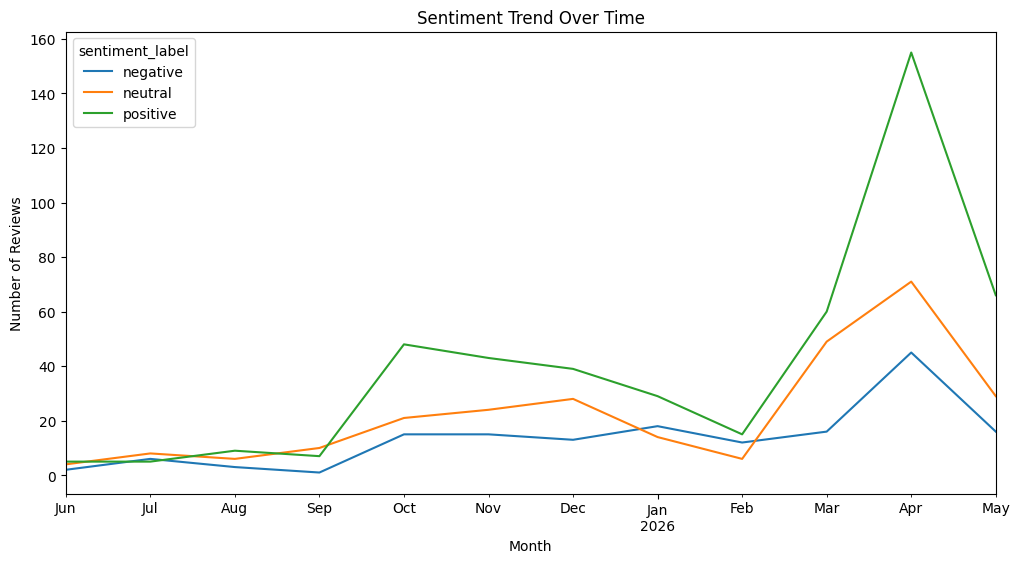

In [20]:
trend = df.groupby([df['date'].dt.to_period('M'), 'sentiment_label']).size().unstack()

trend.plot(figsize=(12,6))
plt.title("Sentiment Trend Over Time")
plt.xlabel("Month")
plt.ylabel("Number of Reviews")
plt.show()

In [23]:
df["sentiment_label"] = df["sentiment_label"].str.strip().str.lower()

In [24]:
positive = df[df["sentiment_label"] == "positive"]
negative = df[df["sentiment_label"] == "negative"]

In [25]:
positive.groupby(["bank", "identified_theme"]).size().sort_values(ascending=False)

bank    identified_theme       
Dashen  UI & Design                83
CBE     Other                      81
Dashen  Other                      63
CBE     UI & Design                58
BOA     Other                      57
        UI & Design                52
Dashen  Transaction Performance    15
CBE     Customer Support           15
        Transaction Performance    13
Dashen  Account Access Issues       9
        Customer Support            8
BOA     Customer Support            7
        Account Access Issues       4
CBE     Feature Requests            4
BOA     Transaction Performance     4
Dashen  Feature Requests            4
CBE     Account Access Issues       2
BOA     Feature Requests            2
dtype: int64

In [26]:
print(df["sentiment_label"].value_counts())

sentiment_label
positive    481
neutral     270
negative    162
Name: count, dtype: int64


In [27]:
positive = df[df["sentiment_label"] == "positive"]
negative = df[df["sentiment_label"] == "negative"]
neutral = df[df["sentiment_label"] == "neutral"]

In [28]:
positive.groupby(["bank", "identified_theme"]).size().sort_values(ascending=False)

bank    identified_theme       
Dashen  UI & Design                83
CBE     Other                      81
Dashen  Other                      63
CBE     UI & Design                58
BOA     Other                      57
        UI & Design                52
Dashen  Transaction Performance    15
CBE     Customer Support           15
        Transaction Performance    13
Dashen  Account Access Issues       9
        Customer Support            8
BOA     Customer Support            7
        Account Access Issues       4
CBE     Feature Requests            4
BOA     Transaction Performance     4
Dashen  Feature Requests            4
CBE     Account Access Issues       2
BOA     Feature Requests            2
dtype: int64

In [29]:
negative.groupby(["bank", "identified_theme"]).size().sort_values(ascending=False)

bank    identified_theme       
BOA     UI & Design                37
Dashen  UI & Design                21
BOA     Other                      21
Dashen  Other                      15
CBE     Other                      13
        UI & Design                11
        Transaction Performance     9
Dashen  Transaction Performance     9
CBE     Account Access Issues       5
BOA     Account Access Issues       4
Dashen  Customer Support            3
BOA     Transaction Performance     3
        Customer Support            3
Dashen  Feature Requests            3
CBE     Customer Support            2
Dashen  Account Access Issues       2
BOA     Feature Requests            1
dtype: int64

🟠 BOA INSIGHTS
⭐ Satisfaction Drivers
BOA received the highest number of positive reviews related to UI & Design (37 mentions), suggesting users appreciate the application’s usability and interface design.
Positive feedback also appeared in Transaction Performance, indicating that many users experience smooth banking operations.
Business Meaning

BOA performs strongly in customer-facing experience and usability, which positively influences customer satisfaction.

❌ Pain Points
BOA also received a significant number of negative reviews concerning UI & Design (52 mentions), indicating inconsistent user experiences across devices or app versions.
Negative feedback related to Customer Support and Account Access Issues suggests some users struggle with issue resolution and authentication problems.
Business Meaning

Although BOA has strong usability strengths, inconsistent interface performance and support responsiveness remain important challenges.

🔵 DASHEN INSIGHTS
⭐ Satisfaction Drivers
Dashen users frequently praised the app’s UI & Design (21 positive mentions).
Positive sentiment also appeared around Transaction Performance, suggesting acceptable functionality for routine banking activities.
Business Meaning

Dashen’s interface and navigation contribute positively to customer experience.

❌ Pain Points
Dashen recorded the highest negative mentions in UI & Design (83 mentions), indicating widespread dissatisfaction with app usability or stability.
Negative reviews also highlighted Transaction Performance and Account Access Issues.
Business Meaning

Usability and system reliability are major concerns affecting customer trust and satisfaction.

🟢 CBE INSIGHTS
⭐ Satisfaction Drivers
Positive reviews for CBE focused on UI & Design and Transaction Performance, suggesting users value successful banking operations and ease of use.
Some users also expressed satisfaction with customer support services.
Business Meaning

CBE demonstrates relatively stable core banking functionality.

❌ Pain Points
CBE received many negative reviews categorized under Other (81 mentions), suggesting a broad range of unresolved issues.
Additional complaints related to UI & Design and Customer Support indicate ongoing usability and service concerns.
Business Meaning

CBE may require broader system improvements beyond isolated feature fixes.

In [30]:
df.groupby("bank")["sentiment_score"].mean()

bank
BOA       0.109527
CBE       0.240255
Dashen    0.264604
Name: sentiment_score, dtype: float64

In [31]:
df.groupby("bank")["rating"].mean()

bank
BOA       3.357143
CBE       3.976351
Dashen    3.757282
Name: rating, dtype: float64

## Cross-Bank Comparison

- BOA achieved the strongest overall customer sentiment, driven mainly by positive feedback regarding UI design and transaction usability.
- Dashen recorded the highest concentration of UI-related complaints, suggesting significant usability and interface consistency challenges.
- CBE demonstrated relatively balanced transaction-related feedback but showed a broader range of unresolved customer concerns grouped under miscellaneous issues.
- Across all three banks, transaction reliability and application stability emerged as recurring industry-wide pain points.

# Recommendations

## CBE
- Improve customer support responsiveness to address the broad range of unresolved customer concerns.
- Enhance system reliability and reduce transaction-related technical failures.
- Introduce faster issue-resolution mechanisms for failed transactions and login problems.

## BOA
- Improve interface consistency across different app versions and devices.
- Strengthen authentication reliability to reduce login and access-related complaints.
- Enhance customer support channels for quicker resolution of user issues.

## Dashen
- Redesign problematic UI workflows to improve usability and navigation consistency.
- Improve app stability and transaction responsiveness during peak usage periods.
- Optimize backend performance to reduce delays and failed banking operations.

## Industry-Wide Recommendation
- All three banks should prioritize transaction reliability, system stability, and authentication performance, as these emerged as recurring customer pain points across the sector.

# Conclusion

This analysis revealed that customer satisfaction across Ethiopian mobile banking applications is strongly influenced by usability, transaction reliability, and application stability. While each bank demonstrated strengths in UI design and transaction functionality, recurring complaints regarding authentication issues, failed transactions, and inconsistent user experiences highlight important areas for improvement. Addressing these issues can significantly improve customer satisfaction and digital banking adoption.